### Problem Statement 1: Policy Compliance & The Plastic Bottle Ban
**Topic:** Lotka-Volterra Predator-Prey Model

**Scenario:**
A university campus implements a ban on single-use plastic water bottles.
- **Prey ($V$):** The number of **Vendors** violating the ban and selling bottles. They "grow" (profit) when student demand is high.
- **Predator ($S$):** The number of **Students** buying from *outside* sources (Amazon, off-campus shops).

**The Dynamics:**
1.  **Student Behavior ($S$):** In the absence of on-campus vendors ($V=0$), students are forced to buy outside ($S$ grows logistically to a saturation level $K$). However, as vendors return ($V \uparrow$), it becomes easier to buy on campus, so students stop going outside ($S \downarrow$).
2.  **Vendor Behavior ($V$):** Vendors need "unmet demand" ($S$) to justify the risk of fines. If $S$ is low (everyone has a reusable bottle), vendors vanish due to enforcement pressure (rate $m$). If $S$ is high, vendors proliferate.

**Mathematical Model:**
$$
\begin{aligned}
\frac{dS}{dt} &= r_s S \left(1 - \frac{S}{K}\right) - aSV \\
\frac{dV}{dt} &= bSV - m V
\end{aligned}
$$
*(Note: $S$ acts as the resource/prey, $V$ acts as the consumer/predator)*

**Questions:**
1.  **Stability:** Under what condition on the fine $m$ does the "Corruption-Free Equilibrium" $(S=K, V=0)$ become unstable, allowing vendors to permanently return?
2.  **Simulation:** Simulate the system for 50 weeks. Assume the administration increases the fine $m$ halfway through. What happens to the vendor population?

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

## Analysis Overview

This problem models policy compliance using a modified Lotka-Volterra framework where:
- **Students ($S$)** represent the resource/prey that grows logistically
- **Vendors ($V$)** represent predators that exploit the resource

The key insight: enforcement (fine $m$) acts as a control parameter that can stabilize or destabilize the system.

In [8]:
def bottle_ban_model(state, t, r_s, K, a, b, m_func):
    S, V = state
    m = m_func(t) # Dynamic fine rate
    
    dSdt = r_s * S * (1 - S/K) - a * S * V
    dVdt = b * S * V - m * V
    return [dSdt, dVdt]

In [9]:
# Parameters
r_s = 0.5   # Growth rate of outside demand
K = 1000    # Max outside demand (total students needing water)
a = 0.01    # Rate at which vendors capture outside demand
b = 0.005   # Profit conversion rate for vendors
# m (fine) will be dynamic
# Time steps
t = np.linspace(0, 50, 1000)

In [10]:
# Dynamic fine function: Low fines initially, High fines after week 25
def fine_schedule(t):
    if t < 25:
        return 1.0  # Low fine: Profitable to violate ban
    else:
        return 6.0  # High fine: Not profitable
# Wrapper for odeint
def model_wrapper(state, t):
    return bottle_ban_model(state, t, r_s, K, a, b, fine_schedule)

In [11]:
# Initial conditions: High outside demand, few illicit vendors
initial_state = [800, 5] 
sol = odeint(model_wrapper, initial_state, t)

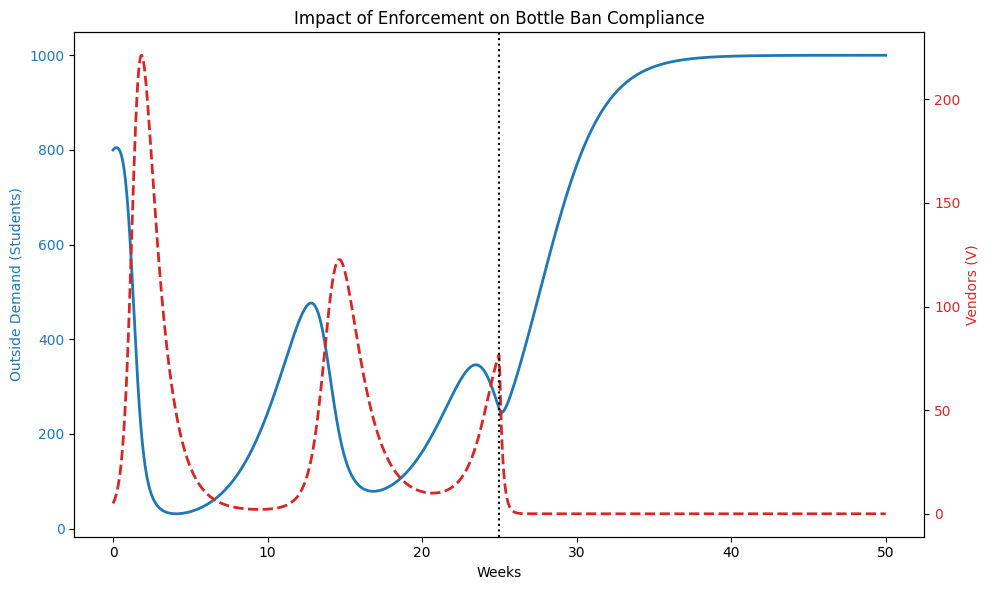

In [12]:
# Plotting
fig, ax1 = plt.subplots(figsize=(10, 6))
color = 'tab:blue'
ax1.set_xlabel('Weeks')
ax1.set_ylabel('Outside Demand (Students)', color=color)
ax1.plot(t, sol[:, 0], color=color, linewidth=2, label='Outside Demand (S)')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  # Instantiate a second axes that shares the same x-axis
color = 'tab:red'
ax2.set_ylabel('Vendors (V)', color=color)
ax2.plot(t, sol[:, 1], color=color, linewidth=2, linestyle='--', label='Vendors (V)')
ax2.tick_params(axis='y', labelcolor=color)

# Mark the policy change
plt.axvline(x=25, color='k', linestyle=':', label='Fine Increase')
plt.title('Impact of Enforcement on Bottle Ban Compliance')
fig.tight_layout()
plt.show()

## Phase Portrait Analysis

Let's visualize the phase space to understand the system dynamics better. We'll plot:
1. Vector field showing flow direction
2. Nullclines (where dS/dt=0 and dV/dt=0)
3. Equilibrium points
4. Trajectory through phase space

In [ ]:
m_low = 1.0
S_range = np.linspace(0, 1200, 25)
V_range = np.linspace(0, 15, 25)
S_grid, V_grid = np.meshgrid(S_range, V_range)
dS = np.zeros_like(S_grid)
dV = np.zeros_like(V_grid)
for i in range(S_grid.shape[0]):
    for j in range(S_grid.shape[1]):
        state = [S_grid[i,j], V_grid[i,j]]
        derivatives = bottle_ban_model(state, 0, r_s, K, a, b, lambda t: m_low)
        dS[i,j] = derivatives[0]
        dV[i,j] = derivatives[1]
M = np.sqrt(dS**2 + dV**2)
M[M==0] = 1
dS_norm, dV_norm = dS/M, dV/M

In [ ]:
plt.figure(figsize=(14, 10))
# Plot vector field
plt.quiver(S_grid, V_grid, dS_norm, dV_norm, M, alpha=0.6, cmap='viridis', scale=30)
# Plot nullclines
S_null = np.linspace(0, K, 200)
# dS/dt = 0: r_s * S * (1 - S/K) - a * S * V = 0
# V = r_s * (1 - S/K) / a
V_nullcline_S = r_s * (1 - S_null/K) / a
plt.plot(S_null, V_nullcline_S, 'r-', linewidth=3, label=r'$\dot{S}=0$ nullcline', alpha=0.8)

# dV/dt = 0: V * (b*S - m) = 0
# V = 0 or S = m/b
S_nullcline_V = m_low / b
plt.axvline(S_nullcline_V, color='b', linewidth=3, linestyle='--', label=r'$\dot{V}=0$ nullcline', alpha=0.8)
plt.axhline(0, color='b', linewidth=3, linestyle='--', alpha=0.8)

# Plot equilibrium points
# (0, 0) and (K, 0) - trivial equilibria
plt.plot(0, 0, 'ko', markersize=12, markerfacecolor='red', label='Equilibria')
plt.plot(K, 0, 'ko', markersize=12, markerfacecolor='red')
# Non-trivial equilibrium: S* = m/b, V* = r_s(1 - m/(bK))/a
S_star = m_low / b
V_star = r_s * (1 - S_star/K) / a
if V_star > 0:
    plt.plot(S_star, V_star, 'ko', markersize=12, markerfacecolor='yellow', label=f'Coexistence: ({S_star:.1f}, {V_star:.2f})')
# Plot actual trajectory
plt.plot(sol[:, 0], sol[:, 1], 'c-', linewidth=3, alpha=0.8, label='System trajectory')
plt.plot(sol[0, 0], sol[0, 1], 'go', markersize=10, label='Initial state')
plt.plot(sol[-1, 0], sol[-1, 1], 'ro', markersize=10, label='Final state')
plt.xlabel('Outside Demand - Students (S)', fontsize=14)
plt.ylabel('Illicit Vendors (V)', fontsize=14)
plt.title('Phase Portrait: Bottle Ban Compliance Dynamics', fontsize=16, fontweight='bold')
plt.xlim(0, 1200)
plt.ylim(0, 15)
plt.legend(fontsize=11, loc='upper right')
plt.grid(True, alpha=0.3)
plt.colorbar(label='Flow magnitude')
plt.tight_layout()

## Stability Analysis

**Question 1 Answer:** The "Corruption-Free Equilibrium" $(S=K, V=0)$ becomes unstable when:

$$m < bK$$

At this point, vendors can invade because the profit from selling to maximum demand exceeds the fine cost.

- Current parameters: $bK = 0.005 \times 1000 = 5$
- Low fine: $m = 1.0 < 5$ → Vendors persist (unstable)
- High fine: $m = 6.0 > 5$ → Vendors eliminated (stable)

Let's visualize the impact of different fine levels:

In [ ]:
# Compare multiple fine levels
fine_levels = [0.5, 1.0, 3.0, 5.0, 6.0, 8.0]
t_compare = np.linspace(0, 100, 2000)
initial_compare = [800, 5]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for idx, m_test in enumerate(fine_levels):
    sol_test = odeint(bottle_ban_model, initial_compare, t_compare, args=(r_s, K, a, b, lambda t: m_test))
    ax = axes[idx]
    ax.plot(t_compare, sol_test[:, 0], 'b-', label='Outside Demand (S)', linewidth=2)
    ax.plot(t_compare, sol_test[:, 1], 'r--', label='Vendors (V)', linewidth=2)
    stability = "Stable (V→0)" if m_test > b*K else "Unstable (V persists)"
    color = 'green' if m_test > b*K else 'red'
    ax.set_title(f'Fine m = {m_test} ({stability})', fontsize=12, fontweight='bold', color=color)
    ax.set_xlabel('Time (weeks)', fontsize=10)
    ax.set_ylabel('Population', fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-10, max(850, sol_test[:, 0].max()))

plt.suptitle(f'Critical Fine Threshold: m_critical = bK = {b*K:.1f}', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()